<a href="https://colab.research.google.com/github/Munaza-maker12/neurofive-ml-track/blob/main/Ensemble_Learning_Random_Forest_vs_XGBoost.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install xgboost -q

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, f1_score

In [2]:
df = sns.load_dataset('titanic')
df = df[['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'embarked']].dropna(subset=['embarked'])
df['age'] = df['age'].fillna(df['age'].median())

df['family_size'] = df['sibsp'] + df['parch'] + 1
df['is_alone'] = (df['family_size'] == 1).astype(int)
df['fare_per_person'] = df['fare'] / df['family_size']

numeric_features = ['age', 'fare', 'family_size', 'fare_per_person']
categorical_features = ['pclass', 'sex', 'embarked', 'is_alone']

X = df.drop('survived', axis=1)
y = df['survived']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

preprocessor = ColumnTransformer(transformers=[
    ('num', StandardScaler(), numeric_features),
    ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
])

In [3]:
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'XGBoost': XGBClassifier(eval_metric='logloss', random_state=42)
}

results = []
fitted_pipelines = {}

for name, model in models.items():
    pipe = Pipeline(steps=[('preprocessor', preprocessor), ('classifier', model)])
    pipe.fit(X_train, y_train)
    preds = pipe.predict(X_test)
    acc = accuracy_score(y_test, preds)
    f1 = f1_score(y_test, preds)
    results.append({'Model': name, 'Accuracy': round(acc, 4), 'F1-Score': round(f1, 4)})
    fitted_pipelines[name] = pipe

results_df = pd.DataFrame(results)
print(results_df)

                 Model  Accuracy  F1-Score
0  Logistic Regression    0.8034    0.7482
1        Random Forest    0.7865    0.7361
2              XGBoost    0.8034    0.7518


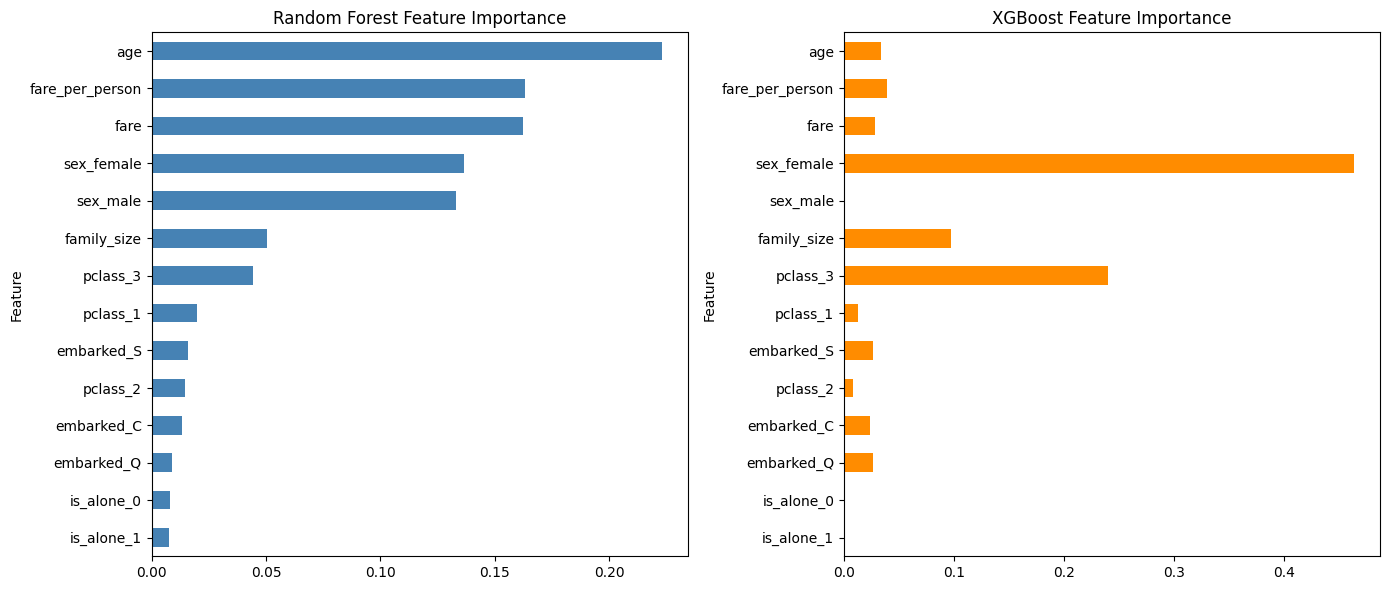

In [4]:
# Get feature names after OneHotEncoding
ohe_features = fitted_pipelines['Random Forest'].named_steps['preprocessor'] \
    .named_transformers_['cat'].get_feature_names_out(categorical_features)
all_feature_names = numeric_features + list(ohe_features)

rf_importances = fitted_pipelines['Random Forest'].named_steps['classifier'].feature_importances_
xgb_importances = fitted_pipelines['XGBoost'].named_steps['classifier'].feature_importances_

importance_df = pd.DataFrame({
    'Feature': all_feature_names,
    'RandomForest': rf_importances,
    'XGBoost': xgb_importances
}).sort_values('RandomForest', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
importance_df.plot.barh(x='Feature', y='RandomForest', ax=axes[0], color='steelblue', legend=False)
axes[0].set_title('Random Forest Feature Importance')
axes[0].invert_yaxis()

importance_df.plot.barh(x='Feature', y='XGBoost', ax=axes[1], color='darkorange', legend=False)
axes[1].set_title('XGBoost Feature Importance')
axes[1].invert_yaxis()

plt.tight_layout()
plt.savefig('feature_importance_comparison.png', dpi=150)
plt.show()

Random Forest builds many decision trees independently in parallel using bootstrapped samples of the data, then combines their predictions through majority voting (bagging). This reduces variance and overfitting since errors from individual trees tend to cancel out. XGBoost, on the other hand, builds trees sequentially (boosting), where each new tree is trained specifically to correct the errors of the previous ones. This sequential error-correction generally makes XGBoost more accurate on structured/tabular data, though it's more prone to overfitting if not tuned carefully (via learning rate, max depth, regularization).

In [5]:
readme_table = results_df.to_markdown(index=False)
print(readme_table)

# Save to a file you can paste into your repo's README.md
with open('model_comparison.md', 'w') as f:
    f.write("## Model Comparison\n\n")
    f.write(readme_table)

| Model               |   Accuracy |   F1-Score |
|:--------------------|-----------:|-----------:|
| Logistic Regression |     0.8034 |     0.7482 |
| Random Forest       |     0.7865 |     0.7361 |
| XGBoost             |     0.8034 |     0.7518 |
